In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("data/city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Filter one city (important for time series)
df = df[df['City'] == 'Kolkata']

# Sort by date
df = df.sort_values('Date')

# Set index
df.set_index('Date', inplace=True)

# Handle missing values
df = df.fillna(method='ffill')

df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_19056\1392418216.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2018-04-10,Kolkata,34.38,57.00,NaN,40.97,NaN,2.52,1.00,25.46,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-11,Kolkata,29.00,50.87,3.26,34.03,45.29,3.59,0.98,10.32,30.99,4.64,0.88,NaN,73.0,Satisfactory
2018-04-12,Kolkata,21.70,43.04,3.49,39.49,42.54,3.77,0.73,10.32,43.72,5.33,1.76,NaN,60.0,Satisfactory
2018-04-13,Kolkata,23.09,46.49,3.69,33.03,36.72,3.88,0.98,10.32,41.65,6.78,2.23,NaN,74.0,Satisfactory
2018-04-14,Kolkata,21.56,42.10,2.81,26.62,29.43,4.22,1.00,10.32,44.07,5.09,2.33,NaN,83.0,Satisfactory


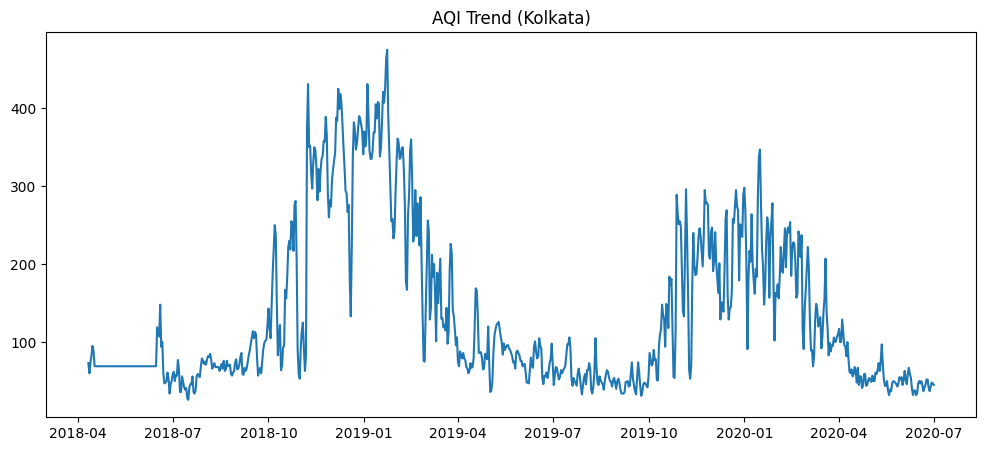

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df['AQI'])
plt.title("AQI Trend (Kolkata)")
plt.show()

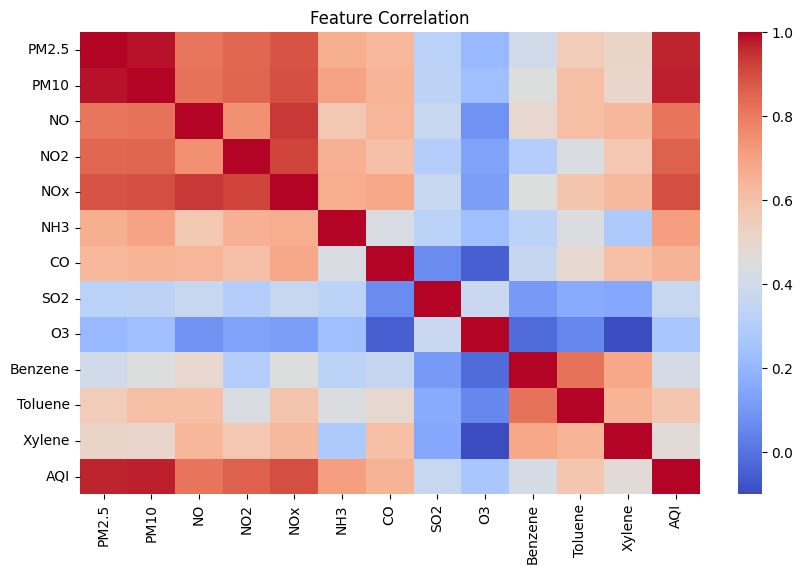

In [6]:
plt.figure(figsize=(10,6))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

In [7]:
# Time features
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.weekday

# Lag features
df['lag_1'] = df['AQI'].shift(1)
df['lag_7'] = df['AQI'].shift(7)

# Rolling features
df['rolling_mean_7'] = df['AQI'].rolling(7).mean()
df['rolling_std_7'] = df['AQI'].rolling(7).std()

df = df.dropna()

df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,Xylene,AQI,AQI_Bucket,day,month,weekday,lag_1,lag_7,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-31,Kolkata,31.79,71.66,4.08,10.25,13.98,5.67,0.40,2.38,19.31,...,3.14,76.0,Satisfactory,31,5,4,83.0,74.0,80.285714,8.280787
2019-06-01,Kolkata,36.25,69.53,3.74,17.79,20.47,4.15,0.40,2.88,26.32,...,6.68,76.0,Satisfactory,1,6,5,76.0,75.0,80.428571,8.182443
2019-06-02,Kolkata,28.84,57.42,10.70,14.42,23.31,5.08,0.36,2.42,24.97,...,6.68,69.0,Satisfactory,2,6,6,76.0,66.0,80.857143,7.335498
2019-06-03,Kolkata,31.32,57.27,4.62,21.29,23.85,4.51,0.43,4.37,50.09,...,6.68,71.0,Satisfactory,3,6,0,69.0,87.0,78.571429,7.590721
2019-06-04,Kolkata,31.93,60.06,7.66,15.65,23.20,4.60,0.37,3.28,31.57,...,4.44,72.0,Satisfactory,4,6,1,71.0,89.0,76.142857,6.309479


In [12]:
df['AQI_Bucket_encoded'] = df['AQI_Bucket'].astype('category').cat.codes
df=df.drop('AQI_Bucket',axis=1)
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_19056\3479876204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AQI_Bucket_encoded'] = df['AQI_Bucket'].astype('category').cat.codes


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,Xylene,AQI,day,month,weekday,lag_1,lag_7,rolling_mean_7,rolling_std_7,AQI_Bucket_encoded
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-31,Kolkata,31.79,71.66,4.08,10.25,13.98,5.67,0.40,2.38,19.31,...,3.14,76.0,31,5,4,83.0,74.0,80.285714,8.280787,3
2019-06-01,Kolkata,36.25,69.53,3.74,17.79,20.47,4.15,0.40,2.88,26.32,...,6.68,76.0,1,6,5,76.0,75.0,80.428571,8.182443,3
2019-06-02,Kolkata,28.84,57.42,10.70,14.42,23.31,5.08,0.36,2.42,24.97,...,6.68,69.0,2,6,6,76.0,66.0,80.857143,7.335498,3
2019-06-03,Kolkata,31.32,57.27,4.62,21.29,23.85,4.51,0.43,4.37,50.09,...,6.68,71.0,3,6,0,69.0,87.0,78.571429,7.590721,3
2019-06-04,Kolkata,31.93,60.06,7.66,15.65,23.20,4.60,0.37,3.28,31.57,...,4.44,72.0,4,6,1,71.0,89.0,76.142857,6.309479,3


In [13]:
X = df.drop(columns=['AQI', 'City'])
y = df['AQI']

# Train-test split (NO shuffle)
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 4.622


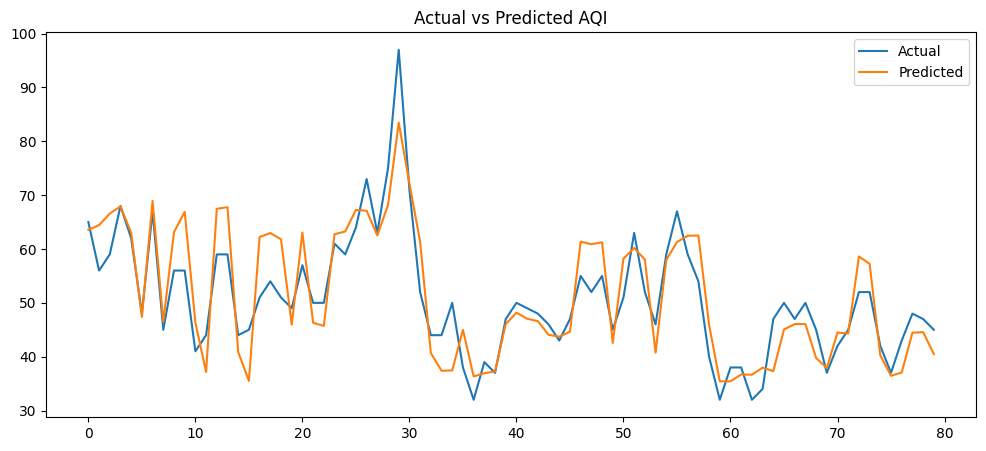

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted AQI")
plt.show()

In [15]:
mean = df['AQI'].mean()
std = df['AQI'].std()

df['z_score'] = (df['AQI'] - mean) / std

df['anomaly'] = np.where(abs(df['z_score']) > 3, 1, 0)

df[df['anomaly'] == 1].head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,day,month,weekday,lag_1,lag_7,rolling_mean_7,rolling_std_7,AQI_Bucket_encoded,z_score,anomaly
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-16,Kolkata,145.88,256.22,103.28,77.25,170.71,35.15,1.79,13.07,38.31,...,16,1,3,338.0,200.0,241.428571,79.803628,4,3.028868,1


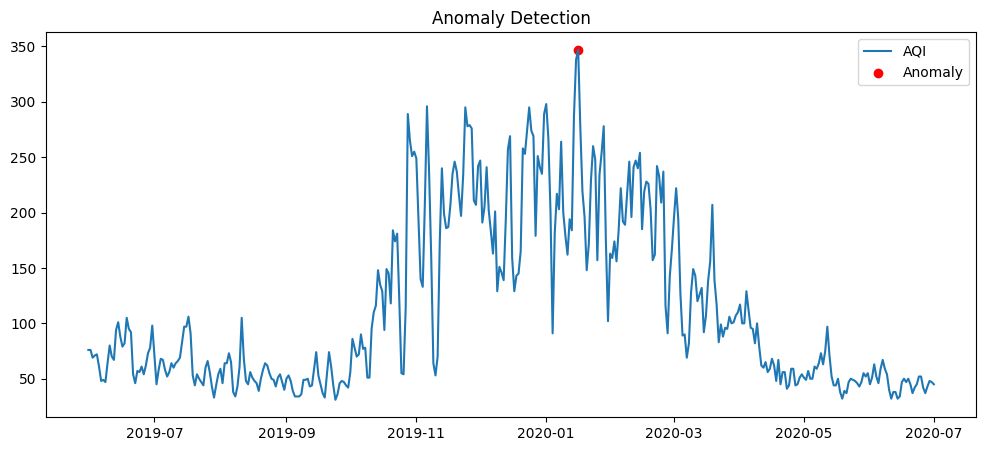

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df['AQI'], label='AQI')

anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['AQI'], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection")
plt.show()

In [17]:
latest = X_test.iloc[-1:]

prediction = model.predict(latest)

print("Next Day AQI Prediction:", prediction[0])

Next Day AQI Prediction: 40.5
